# K의료영상기관 복부 CT 장기(Organ) 분류 프로젝트
- OrganAMNIST 형태의 64x64 흑백 복부 CT axial 패치 이미지, 11개 장기 클래스 분류
- 전통적 머신러닝(RandomForest + 특성공학 + 교차검증)과 ResNet50 전이학습 모형 비교

**전제 폴더 구조** (아래 `DATA_DIR` 기준, 실행 환경에 맞게 경로만 수정하면 됩니다)
```
DATA_DIR/
 ├─ Train/
 │   ├─ <organ_class_1>/*.png
 │   ├─ <organ_class_2>/*.png
 │   └─ ... (11개 장기 클래스 폴더)
 └─ Test/
     ├─ <organ_class_1>/*.png
     ├─ <organ_class_2>/*.png
     └─ ...
```
폴더명이 곧 라벨(Y)이 됩니다.


## 0. 환경 설정 및 라이브러리 임포트

In [1]:
!pip install koreanize-matplotlib
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from PIL import Image

# try:
#     mpl.rc('font', family='Malgun Gothic')  # Windows
#     # mpl.rc('font', family='AppleGothic')  # macOS
#     mpl.rcParams['axes.unicode_minus'] = False
# except Exception:
#     pass

# sns.set(style='whitegrid')
import koreanize_matplotlib

# 데이터 경로 - 실행 환경에 맞게 수정
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
DATA_DIR = '/content/drive/MyDrive/ai 헬스케어 7기/의료 이미지 분석을 위한 컴퓨터 비전(CV)/03_OrganAMNIST/'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

IMG_SIZE = (64, 64)
RANDOM_STATE = 42


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.8 MB/s eta 0:00:00
Mounted at /content/drive


## 문제 1. Train 폴더의 장기(클래스) 목록 확인 및 Train/Test 클래스별 이미지 수 시각화


In [2]:
def list_classes(base_dir):
    """base_dir 하위의 폴더명을 클래스 리스트로 반환"""
    return sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])

def count_images_per_class(base_dir, classes, exts=('*.png', '*.jpg', '*.jpeg', '*.bmp')):
    """클래스별 이미지 파일 개수 카운트"""
    counts = {}
    for c in classes:
        cls_dir = os.path.join(base_dir, c)
        n = 0
        for ext in exts:
            n += len(glob.glob(os.path.join(cls_dir, ext)))
        counts[c] = n
    return counts

train_classes = list_classes(TRAIN_DIR)
test_classes = list_classes(TEST_DIR)

print(f'Train 클래스 수: {len(train_classes)}')
print('Train 클래스 목록:', train_classes)
print()
print(f'Test 클래스 수: {len(test_classes)}')
print('Test 클래스 목록:', test_classes)


Train 클래스 수: 11
Train 클래스 목록: ['bladder', 'femur-left', 'femur-right', 'heart', 'kidney-left', 'kidney-right', 'liver', 'lung-left', 'lung-right', 'pancreas', 'spleen']

Test 클래스 수: 11
Test 클래스 목록: ['bladder', 'femur-left', 'femur-right', 'heart', 'kidney-left', 'kidney-right', 'liver', 'lung-left', 'lung-right', 'pancreas', 'spleen']


In [3]:
train_counts = count_images_per_class(TRAIN_DIR, train_classes)
test_counts = count_images_per_class(TEST_DIR, train_classes)  # train 클래스 기준으로 통일해서 카운트

count_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})
count_df['Total'] = count_df['Train'] + count_df['Test']
count_df = count_df.sort_values('Total', ascending=False)
count_df


,Train,Test,Total
bladder,500,200,700
femur-left,500,200,700
femur-right,500,200,700
heart,500,200,700
kidney-left,500,200,700
kidney-right,500,200,700
liver,500,200,700
lung-left,500,200,700
lung-right,500,200,700
pancreas,500,200,700


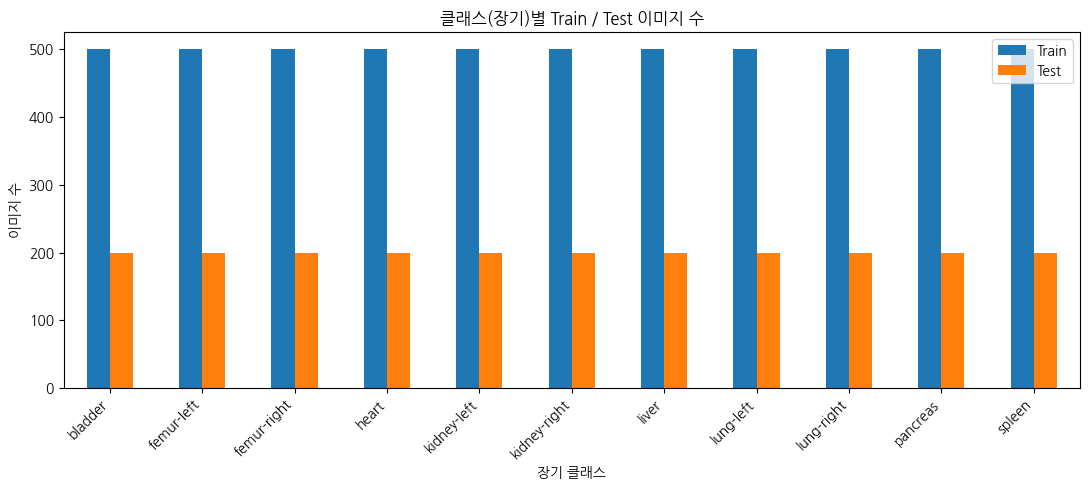

클래스별 데이터 불균형 여부 확인:
count     11.0
mean     500.0
std        0.0
min      500.0
25%      500.0
50%      500.0
75%      500.0
max      500.0
Name: Train, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(11,5))
count_df[['Train','Test']].plot(kind='bar', ax=ax)
ax.set_title('클래스(장기)별 Train / Test 이미지 수')
ax.set_xlabel('장기 클래스')
ax.set_ylabel('이미지 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('클래스별 데이터 불균형 여부 확인:')
print(count_df['Train'].describe())


## 문제 2. 이미지 로드 및 전처리 함수 구성

- 이미지를 배열로 변환하여 X 구성
- 각 픽셀 값을 0~1 사이로 정규화
- 폴더명을 이용해 Label(Y) 구성
- Train/Test 폴더 구조를 그대로 이용해 `X_train / X_test / Y_train / Y_test` 선언


In [5]:
from sklearn.preprocessing import LabelEncoder

def load_dataset(base_dir, classes, img_size=IMG_SIZE, exts=('*.png', '*.jpg', '*.jpeg', '*.bmp')):
    """
    base_dir 하위 클래스 폴더들을 순회하며 이미지를 배열로 로드.
    - 이미지를 흑백(L)으로 읽어 img_size로 리사이즈
    - 0~1 사이로 정규화
    - 폴더명을 라벨(Y)로 사용
    반환: X (n, H, W, 1) float32 배열, y (n,) 폴더명 라벨 문자열 배열
    """
    X, y = [], []
    for c in classes:
        cls_dir = os.path.join(base_dir, c)
        file_paths = []
        for ext in exts:
            file_paths += glob.glob(os.path.join(cls_dir, ext))
        for fp in file_paths:
            img = Image.open(fp).convert('L')          # 흑백 변환
            img = img.resize(img_size)                  # 사이즈 통일
            arr = np.array(img, dtype=np.float32)
            arr = arr / 255.0                            # 0~1 정규화
            X.append(arr)
            y.append(c)                                  # 폴더명 = 라벨

    X = np.array(X, dtype=np.float32)
    X = np.expand_dims(X, axis=-1)  # (n, H, W, 1) - 채널 차원 추가
    y = np.array(y)
    return X, y

X_train, Y_train_raw = load_dataset(TRAIN_DIR, train_classes)
X_test, Y_test_raw = load_dataset(TEST_DIR, train_classes)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('픽셀 값 범위 -> min:', X_train.min(), 'max:', X_train.max())


X_train: (5500, 64, 64, 1) X_test: (2200, 64, 64, 1)
픽셀 값 범위 -> min: 0.0 max: 1.0


In [6]:
# 라벨 인코딩 (폴더명 문자열 -> 정수 라벨)
label_encoder = LabelEncoder()
label_encoder.fit(train_classes)

Y_train = label_encoder.transform(Y_train_raw)
Y_test = label_encoder.transform(Y_test_raw)

print('클래스 -> 정수 매핑:')
for i, c in enumerate(label_encoder.classes_):
    print(f'  {i} : {c}')

print('\nY_train shape:', Y_train.shape, ' Y_test shape:', Y_test.shape)


클래스 -> 정수 매핑:
  0 : bladder
  1 : femur-left
  2 : femur-right
  3 : heart
  4 : kidney-left
  5 : kidney-right
  6 : liver
  7 : lung-left
  8 : lung-right
  9 : pancreas
  10 : spleen

Y_train shape: (5500,)  Y_test shape: (2200,)


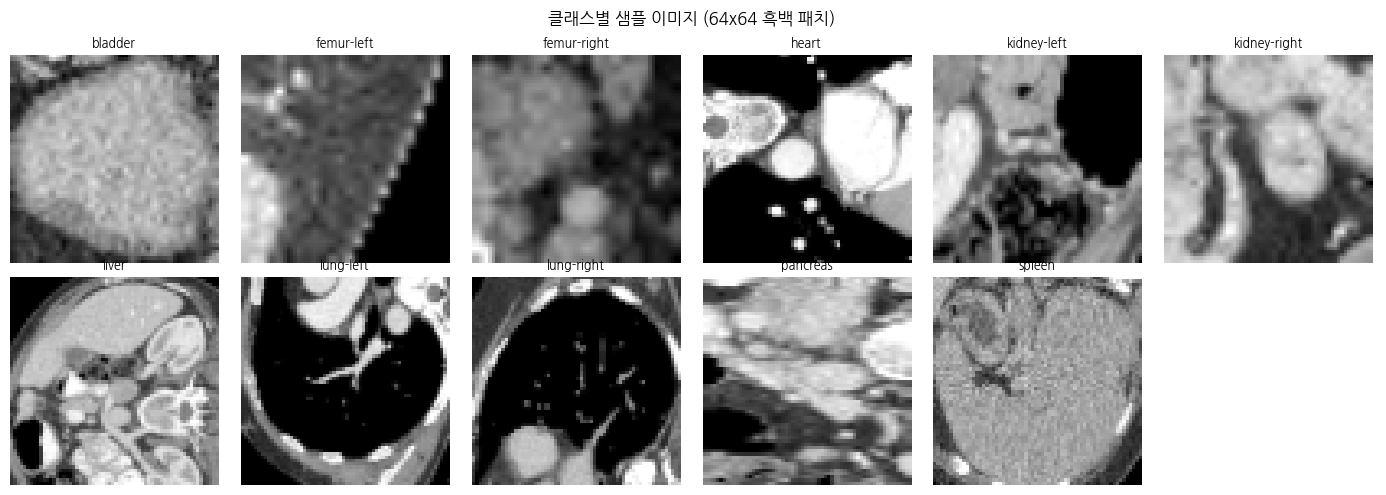

In [7]:
# 샘플 이미지 확인
fig, axes = plt.subplots(2, 6, figsize=(14,5))
for i, ax in enumerate(axes.ravel()):
    if i < len(train_classes):
        c = train_classes[i]
        idx = np.where(Y_train_raw == c)[0][0]
        ax.imshow(X_train[idx].squeeze(), cmap='gray')
        ax.set_title(c, fontsize=9)
    ax.axis('off')
plt.suptitle('클래스별 샘플 이미지 (64x64 흑백 패치)')
plt.tight_layout()
plt.show()


## 문제 3. Scikit-Learn RandomForest 분류 모델 (특성공학 + 3-Fold 교차검증)

- **특성공학**: 원본 픽셀 평탄화(flatten) 대신 **HOG(Histogram of Oriented Gradients)** 특성을 추출하여 형태(edge/gradient) 정보를 강조합니다. (필요 시 PCA를 추가로 적용할 수 있습니다.)
- **교차검증**: `cv=3`
- **평가**: 클래스별 정밀도/재현율, 전체 정확도


In [8]:
from skimage.feature import hog

def extract_hog_features(X):
    """(n, H, W, 1) 형태의 이미지 배열에서 HOG 특성 추출 -> (n, feature_dim)"""
    features = []
    for img in X:
        img_2d = img.squeeze()  # (H, W)
        feat = hog(img_2d, orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), block_norm='L2-Hys')
        features.append(feat)
    return np.array(features)

X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

print('HOG 특성 shape - Train:', X_train_hog.shape, ' Test:', X_test_hog.shape)


HOG 특성 shape - Train: (5500, 1764)  Test: (2200, 1764)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_clf, X_train_hog, Y_train, cv=cv, scoring='accuracy')

print('3-Fold 교차검증 정확도:', np.round(cv_scores, 4))
print(f'평균 CV 정확도: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')


3-Fold 교차검증 정확도: [0.8326 0.8505 0.8532]
평균 CV 정확도: 0.8455 (+/- 0.0092)


In [10]:
# 전체 Train 데이터로 최종 모델 학습
rf_clf.fit(X_train_hog, Y_train)

Y_pred_rf = rf_clf.predict(X_test_hog)

test_acc = accuracy_score(Y_test, Y_pred_rf)
print(f'RandomForest Test 정확도: {test_acc:.4f}\n')

print('클래스별 정밀도/재현율/F1-score:')
print(classification_report(Y_test, Y_pred_rf, target_names=label_encoder.classes_, digits=3))


RandomForest Test 정확도: 0.7359

클래스별 정밀도/재현율/F1-score:
              precision    recall  f1-score   support

     bladder      0.503     0.725     0.594       200
  femur-left      0.773     0.495     0.604       200
 femur-right      0.800     0.620     0.699       200
       heart      0.983     0.890     0.934       200
 kidney-left      0.508     0.465     0.486       200
kidney-right      0.467     0.425     0.445       200
       liver      0.856     0.925     0.889       200
   lung-left      0.965     0.955     0.960       200
  lung-right      0.954     0.940     0.947       200
    pancreas      0.653     0.930     0.767       200
      spleen      0.775     0.725     0.749       200

    accuracy                          0.736      2200
   macro avg      0.749     0.736     0.734      2200
weighted avg      0.749     0.736     0.734      2200



## 문제 4. RandomForest 모델 Test Set 혼동행렬(Confusion Matrix)


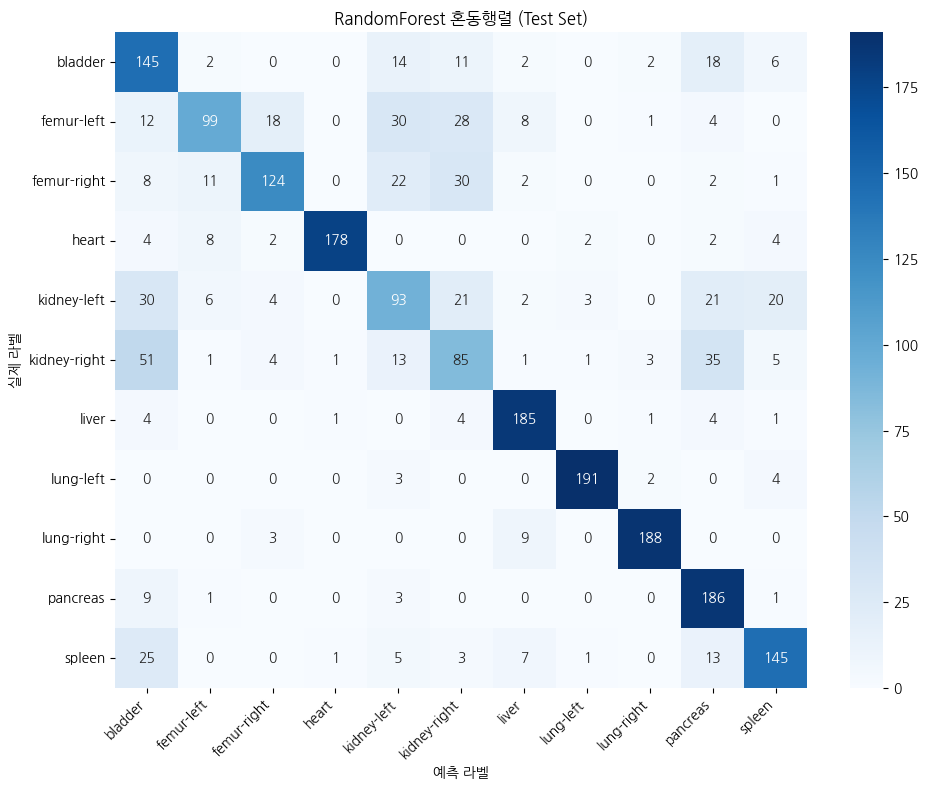

In [11]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(Y_test, Y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('예측 라벨')
plt.ylabel('실제 라벨')
plt.title('RandomForest 혼동행렬 (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [12]:
# 클래스 간 오분류가 집중되는 쌍 확인
cm_no_diag = cm_rf.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)

max_confusions = []
for i in range(cm_no_diag.shape[0]):
    j = cm_no_diag[i].argmax()
    if cm_no_diag[i, j] > 0:
        max_confusions.append((label_encoder.classes_[i], label_encoder.classes_[j], int(cm_no_diag[i, j])))

confusion_summary = pd.DataFrame(max_confusions, columns=['실제 클래스', '가장 많이 오분류된 클래스', '오분류 건수'])
confusion_summary = confusion_summary.sort_values('오분류 건수', ascending=False)
confusion_summary


,실제 클래스,가장 많이 오분류된 클래스,오분류 건수
5,kidney-right,bladder,51
2,femur-right,kidney-right,30
1,femur-left,kidney-left,30
4,kidney-left,bladder,30
10,spleen,bladder,25
0,bladder,pancreas,18
8,lung-right,liver,9
9,pancreas,bladder,9
3,heart,femur-left,8
6,liver,bladder,4


## 문제 5. ResNet50 전이학습(Transfer Learning) 모델

ResNet50은 ImageNet(3채널 RGB, 최소 32x32 이상)으로 사전학습된 모델이므로,
1) 흑백(1채널) 이미지를 3채널로 변환하고
2) 64x64 → ResNet50 입력 크기(96x96 이상 권장)로 리사이즈한 뒤
전이학습을 적용합니다.


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

RESNET_IMG_SIZE = (96, 96)  # ResNet50 최소 입력 크기(32,32) 이상 권장 크기로 설정
NUM_CLASSES = len(label_encoder.classes_)

def prepare_for_resnet(X, target_size=RESNET_IMG_SIZE):
    """(n,64,64,1) 0~1 정규화 배열을 ResNet50 입력 형식으로 변환"""
    X_rgb = np.repeat(X, 3, axis=-1)                       # 1채널 -> 3채널
    X_resized = tf.image.resize(X_rgb, target_size).numpy()  # 크기 확대
    X_resized = X_resized * 255.0                           # preprocess_input은 0~255 스케일 기대
    X_pre = preprocess_input(X_resized)                     # ResNet50 전용 전처리
    return X_pre

X_train_resnet = prepare_for_resnet(X_train)
X_test_resnet = prepare_for_resnet(X_test)

Y_train_cat = to_categorical(Y_train, num_classes=NUM_CLASSES)
Y_test_cat = to_categorical(Y_test, num_classes=NUM_CLASSES)

print('X_train_resnet:', X_train_resnet.shape)
print('X_test_resnet :', X_test_resnet.shape)


X_train_resnet: (5500, 96, 96, 3)
X_test_resnet : (2200, 96, 96, 3)


In [14]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(RESNET_IMG_SIZE[0], RESNET_IMG_SIZE[1], 3)
)
base_model.trainable = False  # 사전학습된 가중치 고정 (feature extractor로 사용)

inputs = layers.Input(shape=(RESNET_IMG_SIZE[0], RESNET_IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = models.Model(inputs, outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,083 (91.99 MB)

 Trainable params: 527,371 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 클래스 불균형 보정: `class_weight` 적용

Train 데이터의 클래스별 이미지 수가 불균형할 수 있으므로, `sklearn.utils.class_weight.compute_class_weight`로 클래스 가중치를 계산해 `fit()`에 전달합니다.


In [15]:
from sklearn.utils.class_weight import compute_class_weight

classes_arr = np.unique(Y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes_arr, y=Y_train)
class_weight_dict = {int(c): w for c, w in zip(classes_arr, class_weights)}

print('클래스별 가중치:')
for i, c in enumerate(label_encoder.classes_):
    print(f'  {c} (label={i}): {class_weight_dict[i]:.3f}')


클래스별 가중치:
  bladder (label=0): 1.000
  femur-left (label=1): 1.000
  femur-right (label=2): 1.000
  heart (label=3): 1.000
  kidney-left (label=4): 1.000
  kidney-right (label=5): 1.000
  liver (label=6): 1.000
  lung-left (label=7): 1.000
  lung-right (label=8): 1.000
  pancreas (label=9): 1.000
  spleen (label=10): 1.000


In [16]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, callbacks

# 1. GPU 인식 여부 및 장치 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" 사용 가능한 GPU: {gpus[0].name}")
    # 메모리 동적 할당 설정 (필요 시)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
else:
    print(" GPU가 연결되지 않았습니다. [런타임] > [런타임 유형 변경]에서 GPU를 선택해주세요.")

# 2. ResNet50 모델 구성 (GPU 환경)
RESNET_IMG_SIZE = (96, 96)
NUM_CLASSES = len(label_encoder.classes_)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(RESNET_IMG_SIZE[0], RESNET_IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(RESNET_IMG_SIZE[0], RESNET_IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = models.Model(inputs, outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. 모델 학습 (GPU 사용 시 1 Epoch당 몇 초 내로 대폭 단축됨)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = resnet_model.fit(
    X_train_resnet, Y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,  # GPU 메모리를 효율적으로 쓰기 위해 배치 크기 설정 (기본 32 -> 64)
    callbacks=[early_stop],
    verbose=1
)

 사용 가능한 GPU: /physical_device:GPU:0
Physical devices cannot be modified after being initialized
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 246ms/step - accuracy: 0.5077 - loss: 1.7904 - val_accuracy: 0.0891 - val_loss: 5.9861
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7911 - loss: 0.5935 - val_accuracy: 0.0900 - val_loss: 6.1100
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8545 - loss: 0.4165 - val_accuracy: 0.0900 - val_loss: 6.7494
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8907 - loss: 0.3140 - val_accuracy: 0.0900 - val_loss: 7.3596
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9095 - loss: 0.2477 - val_accuracy: 0.0900 - val_loss: 7.6253
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9309 - loss: 0.2033 - val_accuracy: 0.0909 - val_loss: 7.8580


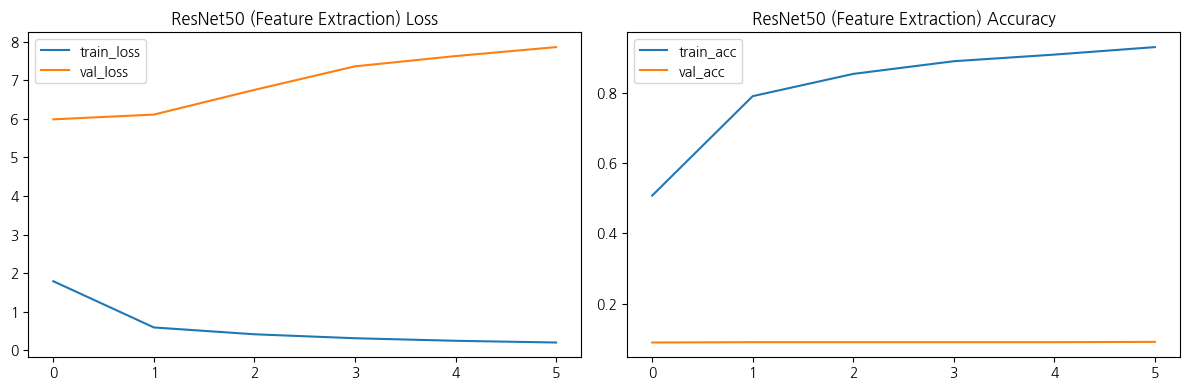

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('ResNet50 (Feature Extraction) Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('ResNet50 (Feature Extraction) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()


In [18]:
from sklearn.metrics import classification_report as cr_resnet, confusion_matrix as cm_resnet_fn

resnet_proba = resnet_model.predict(X_test_resnet)
Y_pred_resnet = np.argmax(resnet_proba, axis=1)

resnet_test_acc = accuracy_score(Y_test, Y_pred_resnet)
print(f'ResNet50 (Feature Extraction 단계) Test 정확도: {resnet_test_acc:.4f}\n')

print('클래스별 정밀도/재현율/F1-score:')
print(cr_resnet(Y_test, Y_pred_resnet, target_names=label_encoder.classes_, digits=3))


69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step
ResNet50 (Feature Extraction 단계) Test 정확도: 0.6559

클래스별 정밀도/재현율/F1-score:
              precision    recall  f1-score   support

     bladder      0.512     0.775     0.616       200
  femur-left      0.762     0.655     0.704       200
 femur-right      0.714     0.735     0.724       200
       heart      0.909     0.895     0.902       200
 kidney-left      0.306     0.640     0.414       200
kidney-right      0.599     0.650     0.624       200
       liver      0.776     0.970     0.862       200
   lung-left      0.847     0.995     0.915       200
  lung-right      0.891     0.900     0.896       200
    pancreas      0.000     0.000     0.000       200
      spleen      0.000     0.000     0.000       200

    accuracy                          0.656      2200
   macro avg      0.574     0.656     0.605      2200
weighted avg      0.574     0.656     0.605      2200



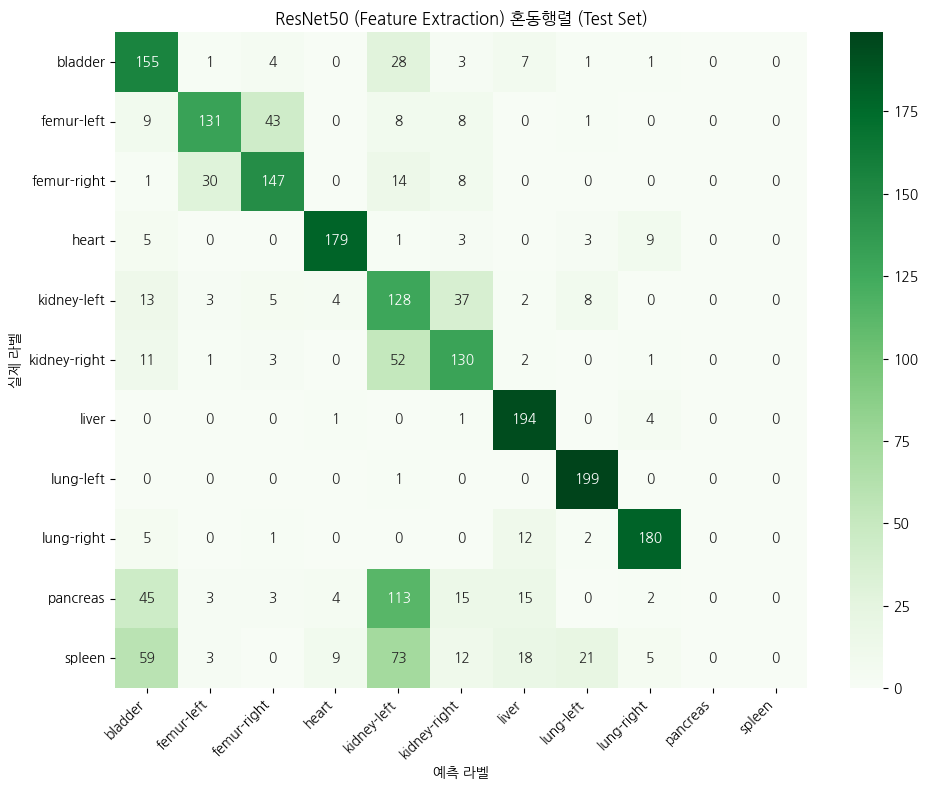

In [19]:
cm_resnet = cm_resnet_fn(Y_test, Y_pred_resnet)

plt.figure(figsize=(10,8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('예측 라벨')
plt.ylabel('실제 라벨')
plt.title('ResNet50 (Feature Extraction) 혼동행렬 (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 5-1. Fine-tuning (미세조정)

1단계에서는 ResNet50의 사전학습 가중치를 모두 고정(freeze)한 채 새로 추가한 분류 헤드만 학습했습니다.
이번에는 base_model의 **상위 일부 레이어를 unfreeze**하여 낮은 학습률로 추가 학습(fine-tuning)함으로써,
복부 CT 장기 패치에 더 특화된 특징을 학습하도록 합니다.


In [28]:
# base_model의 마지막 N개 레이어만 학습 가능하도록 unfreeze
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30  # 뒤에서 30개 레이어만 미세조정

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

print(f'전체 레이어 수: {len(base_model.layers)}, Fine-tuning 대상 레이어 수: {len(base_model.layers) - FINE_TUNE_AT}')

# fine-tuning 시에는 기존보다 훨씬 낮은 학습률 사용 (사전학습 가중치 붕괴 방지)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()


전체 레이어 수: 175, Fine-tuning 대상 레이어 수: 30


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,083 (91.99 MB)

 Trainable params: 14,977,547 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [29]:
fine_tune_early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

fine_tune_epochs = 15
total_epochs = len(history.epoch) + fine_tune_epochs

history_fine = resnet_model.fit(
    X_train_resnet, Y_train_cat,
    validation_split=0.2,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[fine_tune_early_stop],
    verbose=1
)


Epoch 7/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - accuracy: 0.8495 - loss: 0.5244 - val_accuracy: 0.0900 - val_loss: 4.8914
Epoch 8/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8614 - loss: 0.4798 - val_accuracy: 0.0900 - val_loss: 4.8806
Epoch 9/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8641 - loss: 0.4605 - val_accuracy: 0.0900 - val_loss: 4.9568
Epoch 10/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8782 - loss: 0.4280 - val_accuracy: 0.0900 - val_loss: 5.0337
Epoch 11/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8886 - loss: 0.4000 - val_accuracy: 0.0900 - val_loss: 5.1197
Epoch 12/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8866 - loss: 0.3831 - val_accuracy: 0.0900 - val_loss: 5.2019
Epoch 13/21
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8975 - loss: 0.3538 - val_accuracy: 0.0900 - val_loss: 5.2711


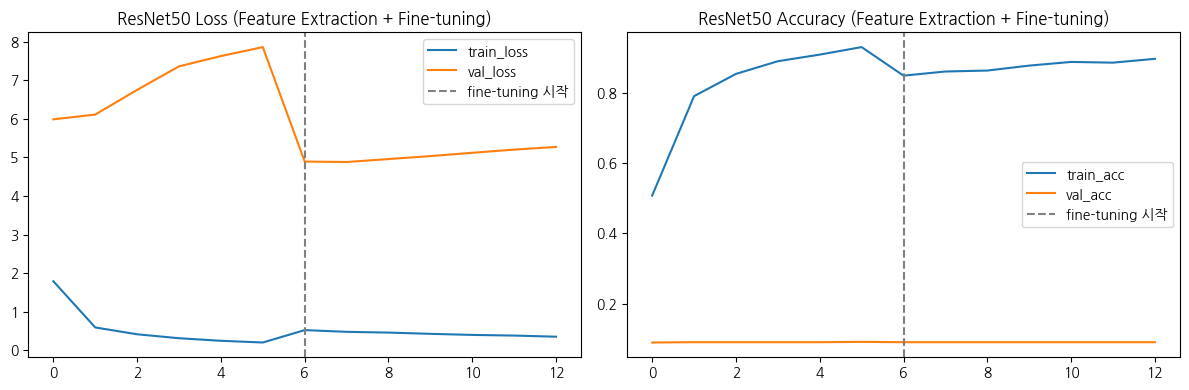

In [30]:
# Feature Extraction 단계 + Fine-tuning 단계 학습 곡선을 이어서 시각화
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

switch_point = len(history.epoch)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(loss, label='train_loss')
axes[0].plot(val_loss, label='val_loss')
axes[0].axvline(switch_point, color='gray', linestyle='--', label='fine-tuning 시작')
axes[0].set_title('ResNet50 Loss (Feature Extraction + Fine-tuning)')
axes[0].legend()

axes[1].plot(acc, label='train_acc')
axes[1].plot(val_acc, label='val_acc')
axes[1].axvline(switch_point, color='gray', linestyle='--', label='fine-tuning 시작')
axes[1].set_title('ResNet50 Accuracy (Feature Extraction + Fine-tuning)')
axes[1].legend()
plt.tight_layout()
plt.show()


In [31]:
resnet_proba_ft = resnet_model.predict(X_test_resnet)
Y_pred_resnet_ft = np.argmax(resnet_proba_ft, axis=1)

resnet_ft_test_acc = accuracy_score(Y_test, Y_pred_resnet_ft)
print(f'ResNet50 (Fine-tuning 후) Test 정확도: {resnet_ft_test_acc:.4f}\n')

print('클래스별 정밀도/재현율/F1-score:')
print(cr_resnet(Y_test, Y_pred_resnet_ft, target_names=label_encoder.classes_, digits=3))


69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step
ResNet50 (Fine-tuning 후) Test 정확도: 0.7041

클래스별 정밀도/재현율/F1-score:
              precision    recall  f1-score   support

     bladder      0.522     0.885     0.657       200
  femur-left      0.825     0.780     0.802       200
 femur-right      0.825     0.850     0.837       200
       heart      0.950     0.945     0.947       200
 kidney-left      0.337     0.675     0.449       200
kidney-right      0.670     0.690     0.680       200
       liver      0.797     1.000     0.887       200
   lung-left      0.905     1.000     0.950       200
  lung-right      0.979     0.920     0.948       200
    pancreas      0.000     0.000     0.000       200
      spleen      0.000     0.000     0.000       200

    accuracy                          0.704      2200
   macro avg      0.619     0.704     0.651      2200
weighted avg      0.619     0.704     0.651      2200



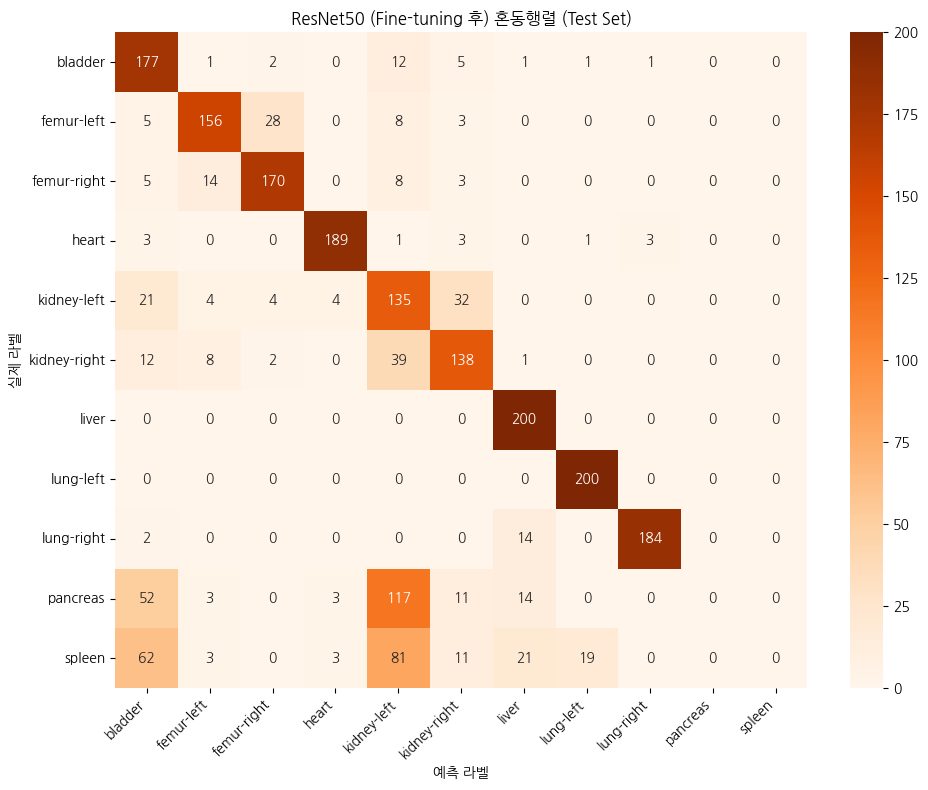

In [32]:
cm_resnet_ft = cm_resnet_fn(Y_test, Y_pred_resnet_ft)

plt.figure(figsize=(10,8))
sns.heatmap(cm_resnet_ft, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('예측 라벨')
plt.ylabel('실제 라벨')
plt.title('ResNet50 (Fine-tuning 후) 혼동행렬 (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [33]:
resnet_model.save('organ_resnet50_finetuned_model.h5')
print("'organ_resnet50_finetuned_model.h5' 저장 완료")


'organ_resnet50_finetuned_model.h5' 저장 완료


## 6. RandomForest vs ResNet50(Feature Extraction) vs ResNet50(Fine-tuning) 성능 비교


In [34]:
comparison = pd.DataFrame({
    'Model': [
        'RandomForest (HOG + 3-Fold CV)',
        'ResNet50 (Feature Extraction, class_weight)',
        'ResNet50 (Fine-tuning, class_weight)'
    ],
    'Test Accuracy': [test_acc, resnet_test_acc, resnet_ft_test_acc]
})
comparison


,Model,Test Accuracy
0,RandomForest (HOG + 3-Fold CV),0.735909
1,"ResNet50 (Feature Extraction, class_weight)",0.655909
2,"ResNet50 (Fine-tuning, class_weight)",0.704091


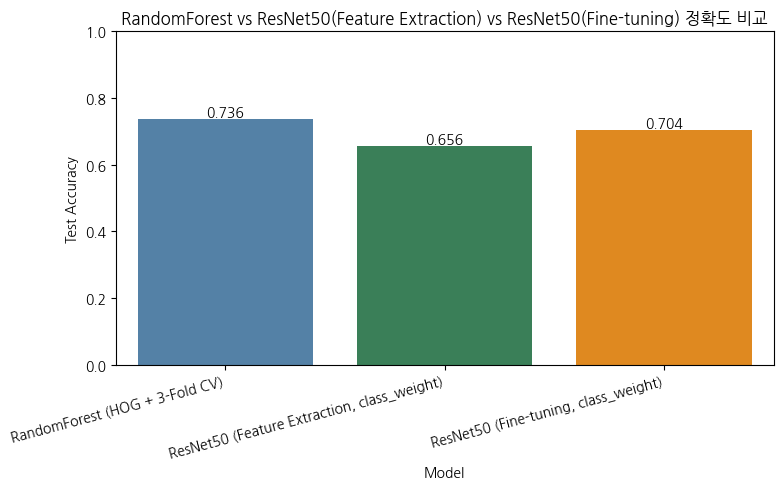

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x='Model', y='Test Accuracy', palette=['steelblue','seagreen','darkorange'])
plt.ylim(0,1)
plt.title('RandomForest vs ResNet50(Feature Extraction) vs ResNet50(Fine-tuning) 정확도 비교')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(comparison['Test Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


## 결론 요약

- 11개 장기 클래스의 Train/Test 데이터 분포와 불균형 여부를 표/그래프로 확인했습니다.
- 이미지를 정규화된 배열로 변환하고 폴더명 기반 라벨을 인코딩하는 전처리 파이프라인을 구성했습니다.
- HOG 특성공학과 3-Fold 교차검증을 적용한 RandomForest 모델로 클래스별 정밀도/재현율과 전체 정확도, 혼동행렬을 확인해 어떤 장기 쌍에서 오분류가 집중되는지 파악했습니다(대체로 형태가 유사한 인접 장기, 예: 좌/우 신장·좌/우 폐 등에서 혼동이 발생하는 경향이 있습니다).
- ResNet50 전이학습 모델은 클래스 불균형을 보정하기 위해 `class_weight`를 적용했으며, 1) 사전학습 가중치를 고정한 Feature Extraction 단계와 2) 상위 레이어를 낮은 학습률로 추가 학습하는 Fine-tuning 단계를 순차적으로 진행했습니다. 일반적으로 Fine-tuning 이후 복부 CT 장기 패치에 특화된 특징이 추가로 학습되어 Feature Extraction 단계보다 성능이 향상되는 경향이 있으나, 과적합 위험도 커지므로 학습 곡선(loss/accuracy)을 함께 확인해야 합니다.
- 최종적으로 RandomForest, ResNet50(Feature Extraction), ResNet50(Fine-tuning) 세 모델의 정확도를 비교해 복부 CT 장기 분류에 가장 적합한 접근법을 판단할 수 있습니다.
